# PRCP-1001 – RiceLeaf Disease Detection

## End-to-end multiclass image-classification project

**Objective:** audit the provided rice-leaf images and train, compare, evaluate, explain, and save deep-learning disease classifiers.  
**Domain:** Agriculture / Computer Vision / Deep Learning  
**Problem type:** multiclass image classification  
**Technologies:** Python, NumPy, Pandas, Pillow, Matplotlib, Seaborn, scikit-learn, TensorFlow/Keras.

All values in this notebook are produced by executed code. No performance results are pre-filled.


# 1. Problem Statement and Business Objective

Rice disease diagnosis from leaf images can support early identification, field monitoring, mobile crop-diagnosis workflows, and expert decision support. The input is a rice-leaf image and the output is one of the actual disease classes discovered from the dataset folders. This is a decision-support tool, not a replacement for agricultural experts.


In [1]:
# 2. Imports and reproducibility
import os, random, json, time, hashlib, zipfile, urllib.request, warnings
from pathlib import Path
os.environ["PYTHONHASHSEED"] = "42"; os.environ["TF_DETERMINISTIC_OPS"] = "1"
SEED = 42; random.seed(SEED); warnings.filterwarnings("ignore")
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from PIL import Image
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
    ANALYSIS_AVAILABLE = True
except ImportError as e:
    ANALYSIS_AVAILABLE = False; print("Install analysis dependencies and rerun:", e)
try:
    import tensorflow as tf
    from tensorflow import keras
    tf.keras.utils.set_random_seed(SEED)
    try: tf.config.experimental.enable_op_determinism()
    except Exception: pass
    DL_AVAILABLE = ANALYSIS_AVAILABLE
except ImportError as e:
    tf = keras = None; DL_AVAILABLE = False
    print("TensorFlow is unavailable; EDA can run, but model training is skipped:", e)
if ANALYSIS_AVAILABLE:
    print(f"NumPy {np.__version__} | Pandas {pd.__version__}")
if DL_AVAILABLE: print("TensorFlow", tf.__version__)
print("TensorFlow training available:", DL_AVAILABLE)


NumPy 2.4.6 | Pandas 3.0.5
TensorFlow 2.21.0
TensorFlow training available: True


# 3. Download / Load Dataset

Set the single variable below to the local folder. The notebook discovers the supplied local folder whose child directories contain images; this preserves actual class names. It does not download data. The folder layout is not assumed.


In [2]:
# The dataset is supplied locally in a sibling folder named "data". No download is used.
DATA_DIR = Path.cwd() / "data"
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset folder not found: {DATA_DIR.resolve()}. "
        "Please ensure the 'data' folder is in the same directory as the notebook."
    )
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
ARTIFACT_DIR = DATA_DIR / "rice_leaf_artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def count_images(folder):
    return sum(p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS for p in folder.rglob("*"))

def find_root(base):
    candidates = [base] + [x for x in base.rglob("*") if x.is_dir()]
    scored = []
    for p in candidates:
        kids = [x for x in p.iterdir() if x.is_dir() and count_images(x)]
        if len(kids) >= 2:
            scored.append((len(kids), sum(count_images(x) for x in kids), p))
    return max(scored, key=lambda x: (x[0], x[1]))[2] if scored else None

dataset_root = find_root(DATA_DIR)
if dataset_root is None:
    raise RuntimeError(f"No image-bearing class folders were found in the supplied local folder: {DATA_DIR.resolve()}")
class_dirs = sorted([x for x in dataset_root.iterdir() if x.is_dir() and count_images(x)], key=lambda x: x.name.lower())
print("Dataset root:", dataset_root.resolve())
for x in class_dirs:
    print(f"  {x.name}: {count_images(x)} image(s)")
print("Discovered classes:", [x.name for x in class_dirs])


Dataset root: /Users/hemanthk/Downloads/Data/data
  Bacterial leaf blight: 40 image(s)
  Brown spot: 40 image(s)
  Leaf smut: 39 image(s)
Discovered classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


# 4. Dataset Structure, Integrity, and Image-Quality Audit

Every supported file is opened and verified before training. The audit reports image dimensions, aspect ratio, size, extensions, unreadable files, repeated filenames, and exact byte-level duplicate images. Unreadable files are not included in the dataset table.


In [3]:
if ANALYSIS_AVAILABLE:
    rows, corrupted = [], []
    for d in class_dirs:
        for p in sorted(d.rglob("*")):
            if not p.is_file() or p.suffix.lower() not in IMAGE_EXTENSIONS: continue
            try:
                with Image.open(p) as im: im.verify()
                with Image.open(p) as im: w,h = im.size
                rows.append({"filename":p.name,"path":str(p.resolve()),"class":d.name,"width":w,"height":h,
                             "aspect_ratio":w/h,"file_size":p.stat().st_size,"extension":p.suffix.lower(),
                             "sha256":hashlib.sha256(p.read_bytes()).hexdigest()})
            except Exception as e: corrupted.append({"path":str(p),"reason":str(e)})
    image_df = pd.DataFrame(rows)
    if image_df.empty: raise RuntimeError("No readable JPG/JPEG/PNG images found.")
    class_names = sorted(image_df["class"].unique()); class_to_index = {x:i for i,x in enumerate(class_names)}
    image_df["label"] = image_df["class"].map(class_to_index)
    duplicate_names = int(image_df.duplicated("filename", keep=False).sum())
    duplicate_images = int(image_df.duplicated("sha256", keep=False).sum())
    audit = pd.DataFrame({"Measure":["Readable images","Number of classes","Corrupted/unreadable","Duplicate filename records","Exact duplicate image records","Images <64 px on either side"],
                          "Value":[len(image_df),len(class_names),len(corrupted),duplicate_names,duplicate_images,len(image_df[(image_df.width<64)|(image_df.height<64)])]})
    display(audit); display(image_df[["filename","class","width","height","aspect_ratio","file_size","extension"]].head())
    display(image_df[["width","height","aspect_ratio","file_size"]].describe().T)
    print("Extensions:", image_df.extension.value_counts().to_dict())
    if corrupted: display(pd.DataFrame(corrupted))
    if duplicate_images: display(image_df[image_df.duplicated("sha256",keep=False)].sort_values("sha256"))


,Measure,Value
0,Readable images,119
1,Number of classes,3
2,Corrupted/unreadable,0
3,Duplicate filename records,0
4,Exact duplicate image records,0
5,Images <64 px on either side,0


,filename,class,width,height,aspect_ratio,file_size,extension
0,DSC_0365.JPG,Bacterial leaf blight,3081,897,3.434783,467109,.jpg
1,DSC_0366.jpg,Bacterial leaf blight,3081,897,3.434783,417929,.jpg
2,DSC_0367.JPG,Bacterial leaf blight,3081,897,3.434783,452625,.jpg
3,DSC_0370.jpg,Bacterial leaf blight,3081,897,3.434783,428732,.jpg
4,DSC_0372.JPG,Bacterial leaf blight,3081,897,3.434783,481489,.jpg


,count,mean,std,min,25%,50%,75%,max
width,119.0,2383.638655,1123.528972,250.00,1074.000000,3081.000000,3081.000000,3081.000000
height,119.0,707.739496,311.657582,71.00,377.000000,897.000000,897.000000,900.000000
aspect_ratio,119.0,3.325255,0.646465,1.25,3.434783,3.434783,3.434783,5.304659
file_size,119.0,315158.100840,176846.290547,23306.00,105123.000000,388554.000000,437120.500000,658844.000000


Extensions: {'.jpg': 119}


# 5. Class Distribution Analysis

Class balance is checked rather than assumed. A class-count ratio (smallest/largest) of at least 0.90 is considered approximately balanced here. Balance matters because raw accuracy can obscure weak performance on an underrepresented disease.


,Class,Images,Percentage
0,Bacterial leaf blight,40,33.61%
1,Brown spot,40,33.61%
2,Leaf smut,39,32.77%


Balance ratio: 0.975 — approximately balanced


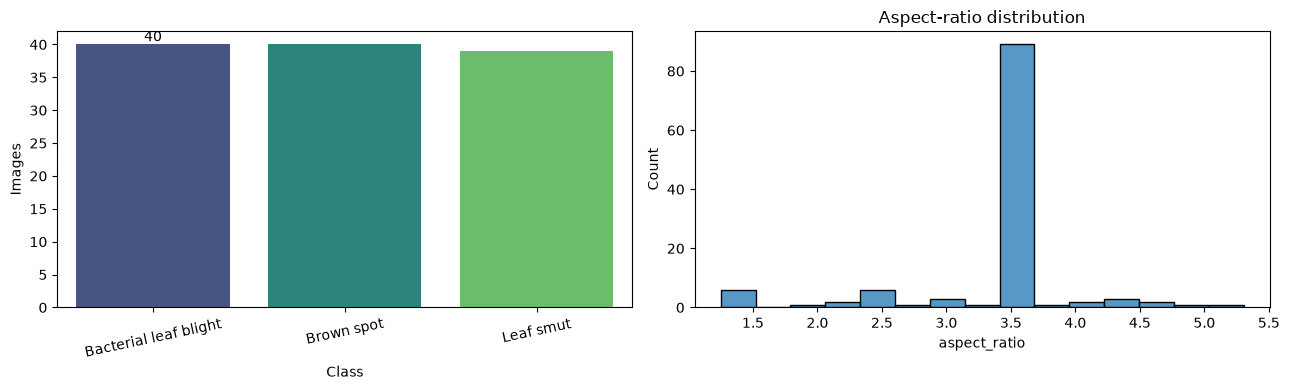

In [4]:
if ANALYSIS_AVAILABLE:
    class_distribution = image_df["class"].value_counts().reindex(class_names).rename_axis("Class").reset_index(name="Images")
    class_distribution["Percentage"] = 100*class_distribution.Images/len(image_df)
    balance_ratio = class_distribution.Images.min()/class_distribution.Images.max()
    display(class_distribution.style.format({"Percentage":"{:.2f}%"}))
    print(f"Balance ratio: {balance_ratio:.3f} —", "approximately balanced" if balance_ratio>=.90 else "not balanced")
    fig,ax=plt.subplots(1,2,figsize=(13,4))
    chart=sns.barplot(data=class_distribution,x="Class",y="Images",ax=ax[0],palette="viridis"); ax[0].bar_label(chart.containers[0]); ax[0].tick_params(axis="x",rotation=12)
    sns.histplot(image_df.aspect_ratio,bins=min(15,len(image_df)),ax=ax[1]); ax[1].set_title("Aspect-ratio distribution")
    plt.tight_layout(); plt.show()


# 6. Image Visualization and Quality Observations

The grids below are the evidence for discussion of background variation, orientation, leaf scale, lighting, blur, and visual symptom variation. Brightness and contrast are quantified; the notebook does not claim a quality problem merely because it is possible.


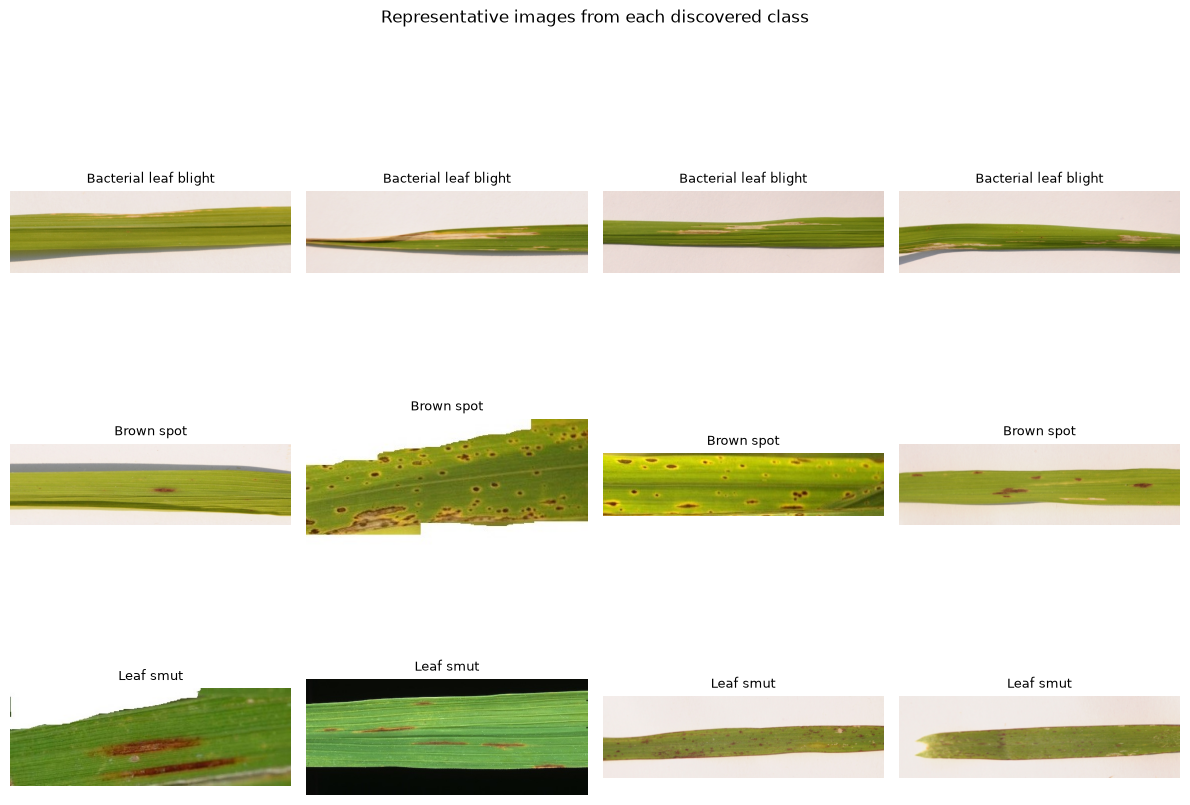

brightness        contrast       
                            mean    std     mean    std
class                                                  
Bacterial leaf blight     186.32  13.23    55.32   4.78
Brown spot                182.86  20.44    49.99  10.85
Leaf smut                 176.78  34.69    55.32  13.32

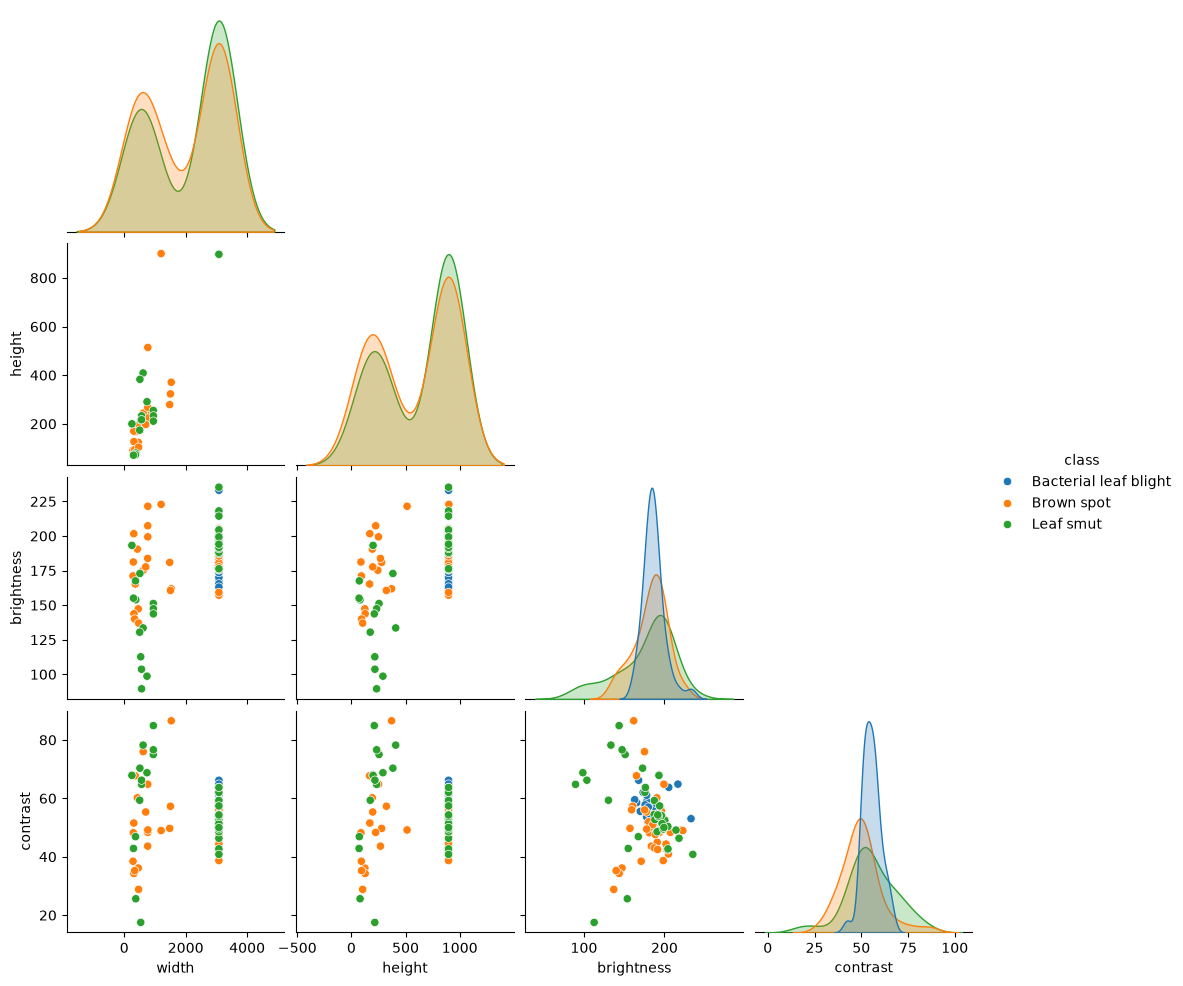

Inspect the displayed images and distributions before drawing conclusions about lighting, backgrounds, orientation, blur, or noise.


In [5]:
if ANALYSIS_AVAILABLE:
    fig,axes=plt.subplots(len(class_names),4,figsize=(12,3*len(class_names))); axes=np.atleast_2d(axes)
    for r,name in enumerate(class_names):
        sample=image_df[image_df["class"]==name].sample(min(4,(image_df["class"]==name).sum()),random_state=SEED)
        for c,(_,row) in enumerate(sample.iterrows()):
            axes[r,c].imshow(Image.open(row.path).convert("RGB")); axes[r,c].set_title(name,fontsize=9); axes[r,c].axis("off")
        for c in range(len(sample),4): axes[r,c].axis("off")
    plt.suptitle("Representative images from each discovered class",y=1.01); plt.tight_layout(); plt.show()
    def quality(path):
        a=np.asarray(Image.open(path).convert("L"),dtype=float); return pd.Series({"brightness":a.mean(),"contrast":a.std()})
    image_df=pd.concat([image_df,image_df.path.apply(quality)],axis=1)
    display(image_df.groupby("class")[["brightness","contrast"]].agg(["mean","std"]).round(2))
    sns.pairplot(image_df[["width","height","brightness","contrast","class"]],hue="class",corner=True); plt.show()
    print("Inspect the displayed images and distributions before drawing conclusions about lighting, backgrounds, orientation, blur, or noise.")


# 7. Preprocessing and Stratified Train / Validation / Test Split

Original files are stratified and split before augmentation (about 70%/15%/15%). The path-disjointness assertion is a leakage check. Training later receives optional random transforms; validation and test only use RGB conversion, resizing to 224×224, and normalization. No augmented image can appear in validation or test.


In [6]:
if ANALYSIS_AVAILABLE:
    train_df, temp_df = train_test_split(image_df, test_size=.30, stratify=image_df.label, random_state=SEED)
    val_df, test_df = train_test_split(temp_df, test_size=.50, stratify=temp_df.label, random_state=SEED)
    train_df, val_df, test_df = (x.reset_index(drop=True) for x in (train_df, val_df, test_df))
    split_table = pd.concat([
        x["class"].value_counts().reindex(class_names, fill_value=0).rename(n)
        for x, n in [(train_df, "Train"), (val_df, "Validation"), (test_df, "Test")]
    ], axis=1)
    split_table.loc["Total"] = split_table.sum()
    display(split_table)
    assert set(train_df.path).isdisjoint(val_df.path)
    assert set(train_df.path).isdisjoint(test_df.path)
    assert set(val_df.path).isdisjoint(test_df.path)
    print(f"Sizes: train={len(train_df)}, validation={len(val_df)}, test={len(test_df)}. Leakage check passed.")

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16

if DL_AVAILABLE:
    N_CLASSES = len(class_names)

    def dataset(frame, kind="standard", shuffle=False):
        ds = tf.data.Dataset.from_tensor_slices((frame.path.astype(str).to_numpy(), frame.label.to_numpy(dtype=np.int32)))
        if shuffle:
            ds = ds.shuffle(len(frame), seed=SEED, reshuffle_each_iteration=True)

        def load(p, y):
            x = tf.io.decode_image(tf.io.read_file(p), channels=3, expand_animations=False)
            x.set_shape([None, None, 3])
            x = tf.cast(tf.image.resize(x, IMAGE_SIZE, antialias=True), tf.float32)
            x = x / 255.0 if kind == "standard" else tf.keras.applications.mobilenet_v2.preprocess_input(x)
            return x, y

        return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    train_ds, val_ds, test_ds = dataset(train_df, shuffle=True), dataset(val_df), dataset(test_df)

    # TensorFlow and pipeline diagnostics run before any model training.
    print("TensorFlow version:", tf.__version__)
    print("Available GPUs:", tf.config.list_physical_devices("GPU"))
    print("Available CPUs:", tf.config.list_physical_devices("CPU"))
    print("Deep Learning Available:", DL_AVAILABLE)
    if not tf.config.list_physical_devices("GPU"):
        print("No GPU detected. Training will run on CPU and may take longer.")

    print("Checking TensorFlow datasets...")
    assert len(train_df) > 0
    assert len(val_df) > 0
    assert len(test_df) > 0
    assert N_CLASSES >= 2
    try:
        for images, labels in train_ds.take(1):
            print("Training batch image shape:", images.shape)
            print("Training batch label shape:", labels.shape)
            print("Training image dtype:", images.dtype)
            print("Training image range:", float(tf.reduce_min(images)), "to", float(tf.reduce_max(images)))
            print("Training labels:", labels.numpy())
        for images, labels in val_ds.take(1):
            print("Validation batch image shape:", images.shape)
        for images, labels in test_ds.take(1):
            print("Test batch image shape:", images.shape)
        print("TensorFlow dataset checks completed successfully.")
    except Exception as exc:
        print("TensorFlow dataset pipeline failed.")
        print("Error Type:", type(exc).__name__)
        print("Error Message:", str(exc))
        raise


,Train,Validation,Test
class,,,
Bacterial leaf blight,28,6,6
Brown spot,28,6,6
Leaf smut,27,6,6
Total,83,18,18


Sizes: train=83, validation=18, test=18. Leakage check passed.
TensorFlow version: 2.21.0
Available GPUs: []
Available CPUs: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Deep Learning Available: True
No GPU detected. Training will run on CPU and may take longer.
Checking TensorFlow datasets...
Training batch image shape: (16, 224, 224, 3)
Training batch label shape: (16,)
Training image dtype: <dtype: 'float32'>
Training image range: 0.0 to 1.000000238418579
Training labels: [1 1 1 2 1 1 0 2 1 1 2 2 2 1 0 1]
Validation batch image shape: (16, 224, 224, 3)
Test batch image shape: (16, 224, 224, 3)
TensorFlow dataset checks completed successfully.


# 8. Baseline CNN Model

A compact convolutional network is appropriate for the small training set: Conv2D → ReLU → max pooling blocks, global average pooling, dense layer, dropout, and softmax. Early stopping, learning-rate reduction, and checkpoints select validation performance without using test labels.



EXPERIMENT 1: BASELINE CNN
Training Images: 83
Validation Images: 18
Test Images: 18
Image Size: (224, 224)
Batch Size: 16
Number of Classes: 3
BASELINE CNN TRAINING STARTED


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 48)   │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,259 (243.20 KB)

 Trainable params: 62,259 (243.20 KB)

 Non-trainable params: 0 (0.00 B)


Running a test forward pass...
Forward pass successful.
Prediction shape: (2, 3)

Starting model training...
Epoch progress will appear below.

Epoch 1/50

Epoch 1: val_loss improved from None to 1.11046, saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/baseline_best.keras

Epoch 1: finished saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/baseline_best.keras
6/6 - 3s - 465ms/step - accuracy: 0.3253 - loss: 1.1188 - val_accuracy: 0.4444 - val_loss: 1.1105 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.11046 to 1.10534, saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/baseline_best.keras

Epoch 2: finished saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/baseline_best.keras
6/6 - 2s - 256ms/step - accuracy: 0.3012 - loss: 1.1191 - val_accuracy: 0.5000 - val_loss: 1.1053 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 1.10534 to 1.09801, saving model to 

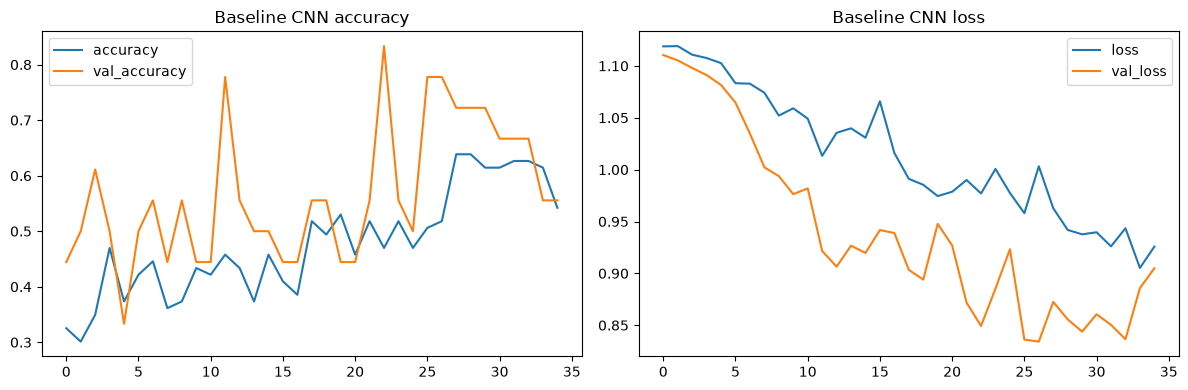

Baseline CNN test metrics: {'Accuracy': 0.5555555555555556, 'Precision': 0.5833333333333334, 'Recall': 0.5555555555555556, 'F1': 0.5416666666666666}


,precision,recall,f1-score,support
Bacterial leaf blight,0.5000,0.3333,0.4000,6.0000
Brown spot,0.7500,0.5000,0.6000,6.0000
Leaf smut,0.5000,0.8333,0.6250,6.0000
accuracy,0.5556,0.5556,0.5556,0.5556
weighted avg,0.5833,0.5556,0.5417,18.0000


In [7]:
if DL_AVAILABLE:
    # Defined before every experiment so restart-kernel/run-all is fully sequential.
    runs = {}
    ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

    def make_callbacks(name):
        return [
            keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=.5, min_lr=1e-6, verbose=1),
            keras.callbacks.ModelCheckpoint(
                filepath=str(ARTIFACT_DIR / f"{name}_best.keras"),
                monitor="val_loss", save_best_only=True, verbose=1,
            ),
        ]

    def print_experiment_details(experiment_name):
        print("\n" + "=" * 70)
        print(experiment_name)
        print("=" * 70)
        print(f"Training Images: {len(train_df)}")
        print(f"Validation Images: {len(val_df)}")
        print(f"Test Images: {len(test_df)}")
        print(f"Image Size: {IMAGE_SIZE}")
        print(f"Batch Size: {BATCH_SIZE}")
        print(f"Number of Classes: {N_CLASSES}")

    def cnn(augment=False):
        inp = keras.Input((*IMAGE_SIZE, 3))
        x = inp
        if augment:
            x = keras.Sequential([
                keras.layers.RandomFlip("horizontal", seed=SEED),
                keras.layers.RandomRotation(.08, fill_mode="reflect", seed=SEED),
                keras.layers.RandomZoom(.10, .10, fill_mode="reflect", seed=SEED),
                keras.layers.RandomTranslation(.08, .08, fill_mode="reflect", seed=SEED),
                keras.layers.RandomContrast(.10, seed=SEED),
            ], name="training_only_augmentation")(x)
        for filters in (24, 48, 96):
            x = keras.layers.Conv2D(filters, 3, padding="same", activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
            x = keras.layers.MaxPooling2D()(x)
        x = keras.layers.GlobalAveragePooling2D()(x)
        x = keras.layers.Dense(96, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
        x = keras.layers.Dropout(.35, seed=SEED)(x)
        out = keras.layers.Dense(N_CLASSES, activation="softmax")(x)
        model = keras.Model(inp, out)
        model.compile(keras.optimizers.Adam(1e-3), "sparse_categorical_crossentropy", metrics=["accuracy"])
        return model

    def counts(model):
        trainable = int(sum(np.prod(x.shape) for x in model.trainable_weights))
        non_trainable = int(sum(np.prod(x.shape) for x in model.non_trainable_weights))
        return trainable + non_trainable, trainable, non_trainable

    def evaluate(model, ds, frame):
        probabilities = model.predict(ds, verbose=0)
        y_true = frame.label.to_numpy()
        y_pred = probabilities.argmax(1)
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
        report = pd.DataFrame(classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)).T
        return {"Accuracy": accuracy_score(y_true, y_pred), "Precision": precision, "Recall": recall, "F1": f1}, report, y_true, y_pred, probabilities

    def curves(history, title):
        history_df = pd.DataFrame(history.history)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        history_df[["accuracy", "val_accuracy"]].plot(ax=axes[0], title=title + " accuracy")
        history_df[["loss", "val_loss"]].plot(ax=axes[1], title=title + " loss")
        plt.tight_layout()
        plt.show()

    print_experiment_details("EXPERIMENT 1: BASELINE CNN")
    print("=" * 60)
    print("BASELINE CNN TRAINING STARTED")
    print("=" * 60)
    baseline = cnn()
    baseline_callbacks = make_callbacks("baseline")
    baseline.summary()

    try:
        sample_images, sample_labels = next(iter(train_ds.take(1)))
        print("\nRunning a test forward pass...")
        sample_predictions = baseline(sample_images[:2], training=False)
        print("Forward pass successful.")
        print("Prediction shape:", sample_predictions.shape)
        print("\nStarting model training...")
        print("Epoch progress will appear below.\n")
        baseline_start_time = time.perf_counter()
        hist = baseline.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=baseline_callbacks, verbose=2)
        baseline_elapsed = time.perf_counter() - baseline_start_time
    except Exception as exc:
        print("\nBASELINE CNN TRAINING FAILED")
        print("Error Type:", type(exc).__name__)
        print("Error Message:", str(exc))
        raise

    print("\n" + "=" * 60)
    print("BASELINE CNN TRAINING COMPLETED")
    print("=" * 60)
    print(f"Training Time: {baseline_elapsed:.2f} seconds")
    curves(hist, "Baseline CNN")
    met, report, y, pred, prob = evaluate(baseline, test_ds, test_df)
    total, trainable, non_trainable = counts(baseline)
    runs["Baseline CNN"] = {"model": baseline, "history": hist, "metrics": met, "report": report, "y": y, "pred": pred, "prob": prob, "time": baseline_elapsed, "parameters": total, "trainable": trainable, "nontrainable": non_trainable, "augmentation": "No", "transfer": "No", "kind": "standard"}
    print("Baseline CNN test metrics:", met)
    display(report.loc[class_names + ["accuracy", "weighted avg"]].round(4))


# 9. Baseline Evaluation and Overfitting Check

Accuracy, weighted precision/recall/F1, class-level metrics, and a confusion matrix are computed from the untouched test split. Interpret the training/validation curves above: a large gap or worsening validation loss is evidence of overfitting; it is not assumed.


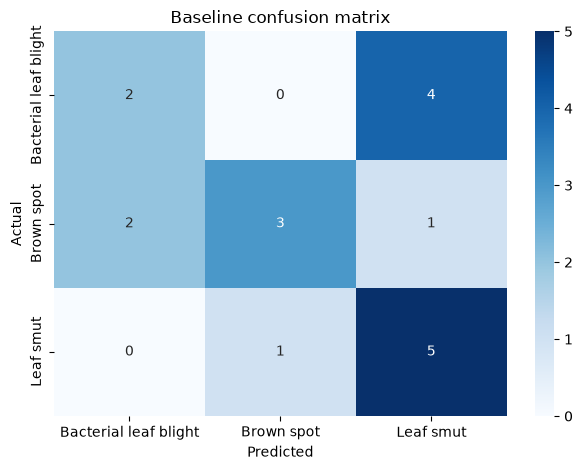

Final train accuracy: 0.5422 | best validation accuracy: 0.8333 | final train/validation gap: -0.0134


In [8]:
if DL_AVAILABLE:
    cm=confusion_matrix(y,pred,labels=np.arange(N_CLASSES))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names); plt.title("Baseline confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()
    h=pd.DataFrame(hist.history); print("Final train accuracy:",round(h.accuracy.iloc[-1],4),"| best validation accuracy:",round(h.val_accuracy.max(),4),"| final train/validation gap:",round(h.accuracy.iloc[-1]-h.val_accuracy.iloc[-1],4))


# 10. Data Augmentation Experiment

The comparison model keeps the CNN architecture, split, seed, optimizer, and metrics comparable. It changes only training-time augmentation: horizontal flip, small rotation, zoom, translation, and contrast adjustment. These are plausible acquisition variations; no transform is applied to validation or test images.



EXPERIMENT 2: CNN WITH DATA AUGMENTATION
Training Images: 83
Validation Images: 18
Test Images: 18
Image Size: (224, 224)
Batch Size: 16
Number of Classes: 3
AUGMENTED CNN TRAINING STARTED


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ training_only_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 24)   │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 24)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 48)   │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 48)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 96)             │         9,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           291 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,259 (243.20 KB)

 Trainable params: 62,259 (243.20 KB)

 Non-trainable params: 0 (0.00 B)


Running a test forward pass...
Forward pass successful.
Prediction shape: (2, 3)

Starting augmented model training...
Epoch progress will appear below.

Epoch 1/50

Epoch 1: val_loss improved from None to 1.11065, saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/augmented_best.keras

Epoch 1: finished saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/augmented_best.keras
6/6 - 3s - 570ms/step - accuracy: 0.2892 - loss: 1.1441 - val_accuracy: 0.3333 - val_loss: 1.1107 - learning_rate: 0.0010
Epoch 2/50

Epoch 2: val_loss improved from 1.11065 to 1.10593, saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/augmented_best.keras

Epoch 2: finished saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/augmented_best.keras
6/6 - 2s - 270ms/step - accuracy: 0.3494 - loss: 1.1117 - val_accuracy: 0.3333 - val_loss: 1.1059 - learning_rate: 0.0010
Epoch 3/50

Epoch 3: val_loss improved from 1.10593 to 1.09824, sa

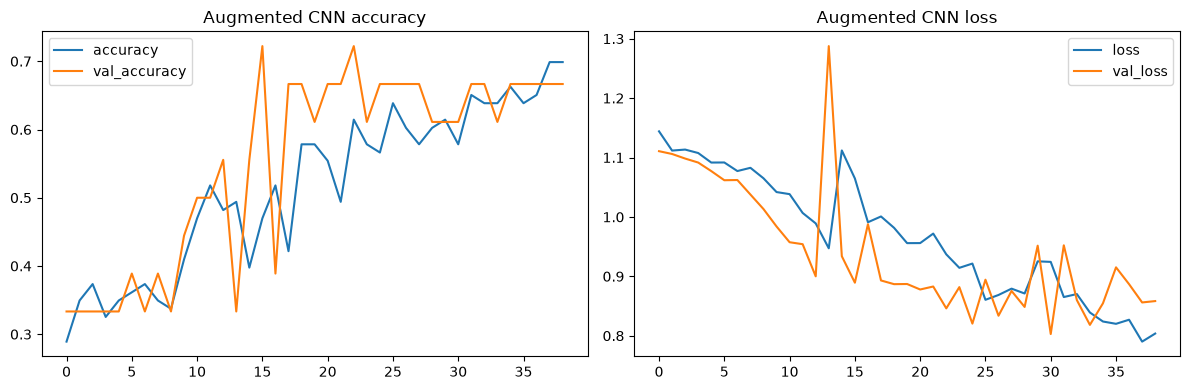

Augmented CNN test metrics: {'Accuracy': 0.4444444444444444, 'Precision': 0.4515151515151515, 'Recall': 0.4444444444444444, 'F1': 0.4006238859180036}


,precision,recall,f1-score,support
Bacterial leaf blight,0.4000,0.3333,0.3636,6.0000
Brown spot,0.5000,0.1667,0.2500,6.0000
Leaf smut,0.4545,0.8333,0.5882,6.0000
accuracy,0.4444,0.4444,0.4444,0.4444
weighted avg,0.4515,0.4444,0.4006,18.0000


,Model,Augmentation,Accuracy,Precision,Recall,F1
0,Baseline CNN,No,0.5556,0.5833,0.5556,0.5417
1,CNN + Data Augmentation,Yes,0.4444,0.4515,0.4444,0.4006


Augmentation F1 change: -0.141 (positive indicates improvement on this test split)


In [9]:
if DL_AVAILABLE:
    print_experiment_details("EXPERIMENT 2: CNN WITH DATA AUGMENTATION")
    print("=" * 60)
    print("AUGMENTED CNN TRAINING STARTED")
    print("=" * 60)
    augmented = cnn(True)
    augmented_callbacks = make_callbacks("augmented")
    augmented.summary()

    try:
        sample_images, sample_labels = next(iter(train_ds.take(1)))
        print("\nRunning a test forward pass...")
        sample_predictions = augmented(sample_images[:2], training=False)
        print("Forward pass successful.")
        print("Prediction shape:", sample_predictions.shape)
        print("\nStarting augmented model training...")
        print("Epoch progress will appear below.\n")
        augmented_start_time = time.perf_counter()
        aug_hist = augmented.fit(train_ds, validation_data=val_ds, epochs=50, callbacks=augmented_callbacks, verbose=2)
        augmented_elapsed = time.perf_counter() - augmented_start_time
    except Exception as exc:
        print("\nAUGMENTED CNN TRAINING FAILED")
        print("Error Type:", type(exc).__name__)
        print("Error Message:", str(exc))
        raise

    print("\n" + "=" * 60)
    print("AUGMENTED CNN TRAINING COMPLETED")
    print("=" * 60)
    print(f"Training Time: {augmented_elapsed:.2f} seconds")
    curves(aug_hist, "Augmented CNN")
    met, report, y, pred, prob = evaluate(augmented, test_ds, test_df)
    total, trainable, non_trainable = counts(augmented)
    runs["CNN + Data Augmentation"] = {"model": augmented, "history": aug_hist, "metrics": met, "report": report, "y": y, "pred": pred, "prob": prob, "time": augmented_elapsed, "parameters": total, "trainable": trainable, "nontrainable": non_trainable, "augmentation": "Yes", "transfer": "No", "kind": "standard"}
    print("Augmented CNN test metrics:", met)
    display(report.loc[class_names + ["accuracy", "weighted avg"]].round(4))
    augmentation_comparison = pd.DataFrame([{"Model": name, "Augmentation": runs[name]["augmentation"], **runs[name]["metrics"]} for name in ["Baseline CNN", "CNN + Data Augmentation"]])
    display(augmentation_comparison.style.format({x: "{:.4f}" for x in ["Accuracy", "Precision", "Recall", "F1"]}))
    print("Augmentation F1 change:", round(runs["CNN + Data Augmentation"]["metrics"]["F1"] - runs["Baseline CNN"]["metrics"]["F1"], 4), "(positive indicates improvement on this test split)")


# 11. Transfer Learning: MobileNetV2

The notebook attempts genuine ImageNet-pretrained MobileNetV2. If its weights are unavailable, it explicitly skips the experiment rather than fabricating a transfer-learning result. Stage 1 freezes the convolutional base; stage 2 cautiously fine-tunes only a small top portion at a very low learning rate. This mitigates the risk of aggressive fine-tuning on ~120 images.



EXPERIMENT 3: TRANSFER LEARNING
Training Images: 83
Validation Images: 18
Test Images: 18
Image Size: (224, 224)
Batch Size: 16
Number of Classes: 3
Attempting to load MobileNetV2 ImageNet weights...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Transfer learning: ImageNet weights loaded


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Running a transfer-learning test forward pass...
Forward pass successful.
Prediction shape: (2, 3)

TRANSFER LEARNING STAGE 1 TRAINING STARTED
Epoch progress will appear below.

Epoch 1/25

Epoch 1: val_loss improved from None to 0.91259, saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/mobilenet_stage1_best.keras

Epoch 1: finished saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/mobilenet_stage1_best.keras
6/6 - 5s - 803ms/step - accuracy: 0.4940 - loss: 1.1557 - val_accuracy: 0.5556 - val_loss: 0.9126 - learning_rate: 0.0010
Epoch 2/25

Epoch 2: val_loss improved from 0.91259 to 0.65386, saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/mobilenet_stage1_best.keras

Epoch 2: finished saving model to /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/mobilenet_stage1_best.keras
6/6 - 1s - 221ms/step - accuracy: 0.6506 - loss: 0.8312 - val_accuracy: 0.8889 - val_loss: 0.6539 - learning_rate: 0.0010
Epoch 3/25

Ep

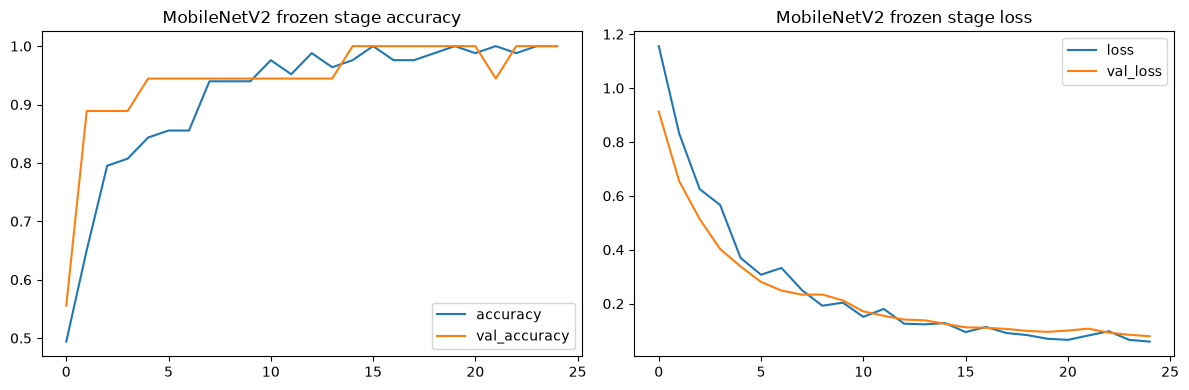

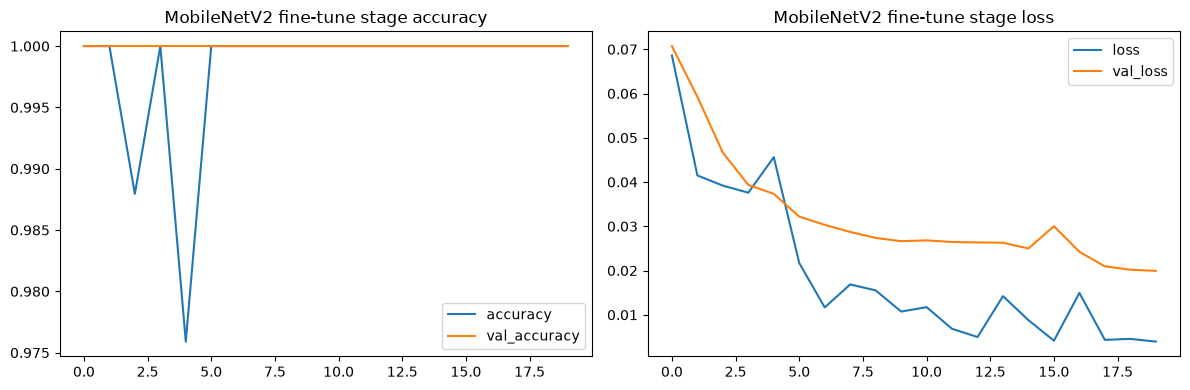

Transfer-learning test metrics: {'Accuracy': 0.8888888888888888, 'Precision': 0.8968253968253967, 'Recall': 0.8888888888888888, 'F1': 0.8885003885003885}


,precision,recall,f1-score,support
Bacterial leaf blight,0.8571,1.0000,0.9231,6.0000
Brown spot,0.8333,0.8333,0.8333,6.0000
Leaf smut,1.0000,0.8333,0.9091,6.0000
accuracy,0.8889,0.8889,0.8889,0.8889
weighted avg,0.8968,0.8889,0.8885,18.0000


In [10]:
TRANSFER_STATUS = "Not attempted"
TRANSFER_AVAILABLE = False
if DL_AVAILABLE:
    print_experiment_details("EXPERIMENT 3: TRANSFER LEARNING")
    print("Attempting to load MobileNetV2 ImageNet weights...")
    try:
        base = keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_shape=(*IMAGE_SIZE, 3))
        TRANSFER_AVAILABLE = True
        TRANSFER_STATUS = "ImageNet weights loaded"
    except Exception as exc:
        TRANSFER_STATUS = f"Skipped: pretrained weights unavailable ({type(exc).__name__}: {exc})"
    print("Transfer learning:", TRANSFER_STATUS)

if DL_AVAILABLE and TRANSFER_AVAILABLE:
    tl_train = dataset(train_df, "mobilenet", True)
    tl_val = dataset(val_df, "mobilenet")
    tl_test = dataset(test_df, "mobilenet")
    base.trainable = False
    inp = keras.Input((*IMAGE_SIZE, 3))
    x = base(inp, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.Dropout(.35, seed=SEED)(x)
    out = keras.layers.Dense(N_CLASSES, activation="softmax")(x)
    transfer = keras.Model(inp, out)
    transfer.compile(keras.optimizers.Adam(1e-3), "sparse_categorical_crossentropy", metrics=["accuracy"])
    transfer_stage1_callbacks = make_callbacks("mobilenet_stage1")
    transfer_finetune_callbacks = make_callbacks("mobilenet_stage2")
    transfer.summary()

    try:
        sample_images, sample_labels = next(iter(tl_train.take(1)))
        print("\nRunning a transfer-learning test forward pass...")
        sample_predictions = transfer(sample_images[:2], training=False)
        print("Forward pass successful.")
        print("Prediction shape:", sample_predictions.shape)
        print("\nTRANSFER LEARNING STAGE 1 TRAINING STARTED")
        print("Epoch progress will appear below.\n")
        transfer_start_time = time.perf_counter()
        h1 = transfer.fit(tl_train, validation_data=tl_val, epochs=25, callbacks=transfer_stage1_callbacks, verbose=2)
        stage1_elapsed = time.perf_counter() - transfer_start_time
        print("\nTRANSFER LEARNING STAGE 1 COMPLETED")
        print(f"Stage 1 Training Time: {stage1_elapsed:.2f} seconds")

        print("\n" + "=" * 70)
        print("EXPERIMENT 3B: TRANSFER LEARNING FINE-TUNING")
        print("=" * 70)
        base.trainable = True
        for layer in base.layers[:-20]:
            layer.trainable = False
        for layer in base.layers:
            if isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = False
        transfer.compile(keras.optimizers.Adam(1e-5), "sparse_categorical_crossentropy", metrics=["accuracy"])
        print("FINE-TUNING STAGE STARTED")
        print("Epoch progress will appear below.\n")
        fine_tune_start_time = time.perf_counter()
        h2 = transfer.fit(tl_train, validation_data=tl_val, epochs=20, callbacks=transfer_finetune_callbacks, verbose=2)
        fine_tune_elapsed = time.perf_counter() - fine_tune_start_time
    except Exception as exc:
        print("\nTRANSFER LEARNING TRAINING FAILED")
        print("Error Type:", type(exc).__name__)
        print("Error Message:", str(exc))
        raise

    transfer_elapsed = stage1_elapsed + fine_tune_elapsed
    print("\n" + "=" * 60)
    print("TRANSFER LEARNING TRAINING COMPLETED")
    print("=" * 60)
    print(f"Fine-Tuning Time: {fine_tune_elapsed:.2f} seconds")
    print(f"Total Training Time: {transfer_elapsed:.2f} seconds")
    curves(h1, "MobileNetV2 frozen stage")
    curves(h2, "MobileNetV2 fine-tune stage")
    met, report, y, pred, prob = evaluate(transfer, tl_test, test_df)
    total, trainable, non_trainable = counts(transfer)
    runs["MobileNetV2 Transfer Learning"] = {"model": transfer, "history": h2, "metrics": met, "report": report, "y": y, "pred": pred, "prob": prob, "time": transfer_elapsed, "parameters": total, "trainable": trainable, "nontrainable": non_trainable, "augmentation": "No", "transfer": "Yes", "kind": "mobilenet"}
    print("Transfer-learning test metrics:", met)
    display(report.loc[class_names + ["accuracy", "weighted avg"]].round(4))


# 12. Model Comparison and Dynamic Best-Model Selection

All table values are calculated from predictions. The selected model is sorted by weighted F1, then accuracy, best validation accuracy, and parameter count. This makes recall/F1 and model complexity part of the decision rather than choosing a model solely by accuracy. Test labels are never used in training, callbacks, augmentation, or preprocessing decisions.


In [11]:
if DL_AVAILABLE:
    comparison=[]
    for n,r in runs.items():
        h=pd.DataFrame(r["history"].history)
        comparison.append({"Model":n,"Augmentation":r["augmentation"],"Transfer Learning":r["transfer"],**r["metrics"],"Parameters":r["parameters"],"Trainable Parameters":r["trainable"],"Non-trainable Parameters":r["nontrainable"],"Training Time (s)":r["time"],"Best Validation Accuracy":h.val_accuracy.max()})
    comparison_df=pd.DataFrame(comparison)
    display(comparison_df.style.format({x:"{:.4f}" for x in ["Accuracy","Precision","Recall","F1","Best Validation Accuracy"]}|{"Parameters":"{:,}","Trainable Parameters":"{:,}","Non-trainable Parameters":"{:,}","Training Time (s)":"{:.1f}"}))
    best_row=comparison_df.sort_values(["F1","Accuracy","Best Validation Accuracy","Parameters"],ascending=[False,False,False,True]).iloc[0]
    best_name=best_row.Model; best=runs[best_name]
    print("Dynamically selected best model:",best_name)


,Model,Augmentation,Transfer Learning,Accuracy,Precision,Recall,F1,Parameters,Trainable Parameters,Non-trainable Parameters,Training Time (s),Best Validation Accuracy
0,Baseline CNN,No,No,0.5556,0.5833,0.5556,0.5417,"62,259","62,259",0,51.8,0.8333
1,CNN + Data Augmentation,Yes,No,0.4444,0.4515,0.4444,0.4006,"62,259","62,259",0,66.5,0.7222
2,MobileNetV2 Transfer Learning,No,Yes,0.8889,0.8968,0.8889,0.8885,"2,261,827","1,198,723","1,063,104",74.9,1.0000


Dynamically selected best model: MobileNetV2 Transfer Learning


# 13. Final Evaluation, Confidence Analysis, Class-Wise Performance, and Error Analysis

The chosen validation-selected candidate is now evaluated on the untouched test set. Each prediction includes the actual label, predicted label, confidence, and correctness. Misclassified images are displayed for evidence-based error review; plausible causes are not asserted without support from the image.


,filename,class,predicted_class,confidence,correct
0,DSC_0336.jpg,Leaf smut,Leaf smut,0.992,True
1,DSC_0304.JPG,Brown spot,Brown spot,0.991,True
2,DSC_0382.JPG,Bacterial leaf blight,Bacterial leaf blight,0.982,True
3,DSC_0700.jpg,Bacterial leaf blight,Bacterial leaf blight,0.877,True
4,DSC_0321.JPG,Leaf smut,Leaf smut,1.000,True
5,DSC_0391.jpg,Brown spot,Brown spot,0.983,True
6,DSC_0330.jpg,Leaf smut,Leaf smut,0.853,True
7,DSC_0500.jpg,Leaf smut,Leaf smut,0.992,True
8,DSC_0392.JPG,Bacterial leaf blight,Bacterial leaf blight,0.995,True
9,DSC_0389.JPG,Bacterial leaf blight,Bacterial leaf blight,1.000,True


Confidence analysis (correctness × confidence ≥0.80):


confidence,False,True
correct,,
False,1,1
True,1,15


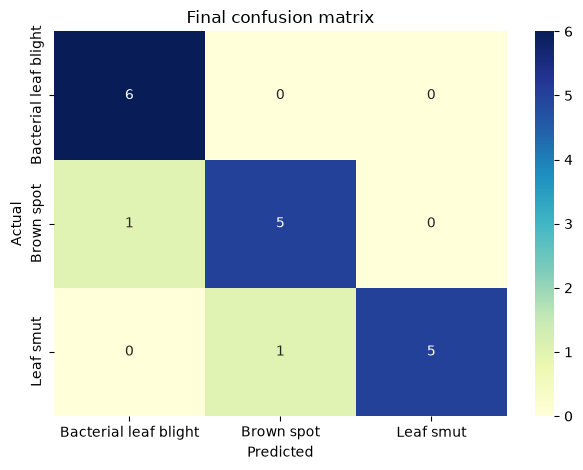

,precision,recall,f1-score,support
Bacterial leaf blight,0.8571,1.0000,0.9231,6.0
Brown spot,0.8333,0.8333,0.8333,6.0
Leaf smut,1.0000,0.8333,0.9091,6.0


Highest recall: Bacterial leaf blight | Lowest recall: Brown spot | Most frequent confusion: Brown spot → Bacterial leaf blight (1 case(s))


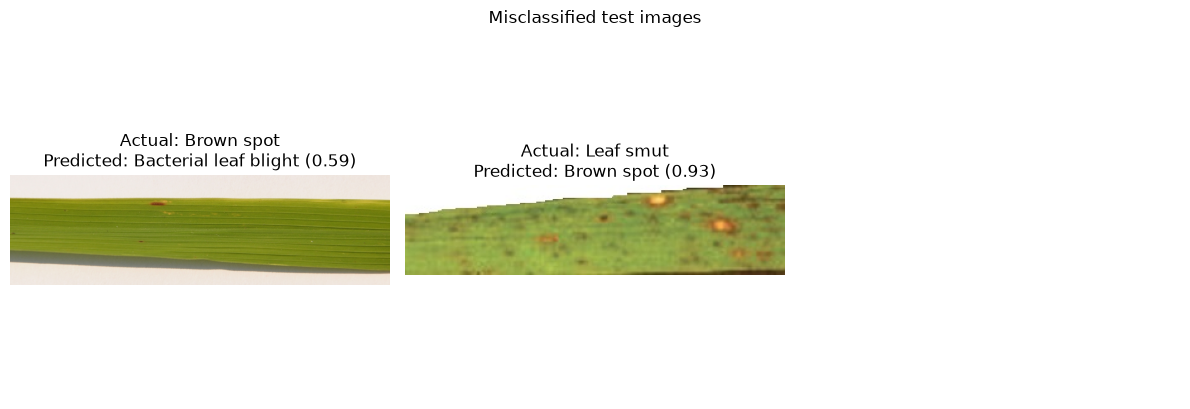

Potential contributors to visible errors may include similar symptoms, lighting, background, orientation, quality, intra-class variation, and small sample size. Inspect the images above before assigning a specific cause.


In [12]:
if DL_AVAILABLE:
    final_ds=dataset(test_df,best["kind"])
    final_metrics,final_report,final_y,final_pred,final_prob=evaluate(best["model"],final_ds,test_df)
    predictions=test_df[["path","filename","class"]].copy(); predictions["predicted_class"]=[class_names[i] for i in final_pred]; predictions["confidence"]=final_prob.max(1); predictions["correct"]=predictions["class"]==predictions.predicted_class
    display(predictions[["filename","class","predicted_class","confidence","correct"]].style.format({"confidence":"{:.3f}"}))
    print("Confidence analysis (correctness × confidence ≥0.80):"); display(pd.crosstab(predictions.correct,predictions.confidence>=.80))
    cm=confusion_matrix(final_y,final_pred,labels=np.arange(N_CLASSES)); sns.heatmap(cm,annot=True,fmt="d",cmap="YlGnBu",xticklabels=class_names,yticklabels=class_names); plt.title("Final confusion matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()
    classwise=final_report.loc[class_names,["precision","recall","f1-score","support"]]; display(classwise.round(4))
    off=cm.copy(); np.fill_diagonal(off,0)
    confused="No test-set confusion" if off.max()==0 else f"{class_names[np.unravel_index(off.argmax(),off.shape)[0]]} → {class_names[np.unravel_index(off.argmax(),off.shape)[1]]} ({off.max()} case(s))"
    print("Highest recall:",classwise.recall.idxmax(),"| Lowest recall:",classwise.recall.idxmin(),"| Most frequent confusion:",confused)
    errors=predictions[~predictions.correct]
    if errors.empty: print("No misclassified test images to display.")
    else:
        fig,axes=plt.subplots(int(np.ceil(len(errors)/3)),3,figsize=(12,4*np.ceil(len(errors)/3))); axes=np.array(axes).reshape(-1)
        for ax,(_,r) in zip(axes,errors.iterrows()): ax.imshow(Image.open(r.path).convert("RGB")); ax.set_title(f"Actual: {r['class']}\nPredicted: {r['predicted_class']} ({r['confidence']:.2f})"); ax.axis("off")
        for ax in axes[len(errors):]: ax.axis("off")
        plt.suptitle("Misclassified test images",y=1.01); plt.tight_layout(); plt.show()
    print("Potential contributors to visible errors may include similar symptoms, lighting, background, orientation, quality, intra-class variation, and small sample size. Inspect the images above before assigning a specific cause.")


# 14. Overfitting, Challenges Faced and Solutions, and Technique Analysis

The next tables turn observed conditions and actual learning curves into a project report. Early stopping, dropout, L2 regularization, and augmentation are safeguards; their effects are evaluated from results, not assumed.


In [13]:
if DL_AVAILABLE:
    overfit=[]
    for n,r in runs.items():
        h=pd.DataFrame(r["history"].history); overfit.append({"Model":n,"Final Train Accuracy":h.accuracy.iloc[-1],"Best Validation Accuracy":h.val_accuracy.max(),"Final Train Loss":h.loss.iloc[-1],"Best Validation Loss":h.val_loss.min(),"Final Accuracy Gap":h.accuracy.iloc[-1]-h.val_accuracy.iloc[-1],"Epochs":len(h)})
    display(pd.DataFrame(overfit).style.format({x:"{:.4f}" for x in ["Final Train Accuracy","Best Validation Accuracy","Final Train Loss","Best Validation Loss","Final Accuracy Gap"]}))
    challenges=pd.DataFrame([
        ["Very small dataset","High variance/overfitting risk","Compact models, stratification, early stopping, dropout","Limits capacity while preserving classes",f"{len(image_df)} usable images"],
        ["Image-size variation","CNN batches need consistent tensors","RGB conversion and 224×224 resize","Standard input contract",f"{image_df[['width','height']].drop_duplicates().shape[0]} unique dimension pairs"],
        ["Class balance","Can hide class weakness","Stratified split and weighted/class-wise metrics","Makes every class visible",f"Balance ratio {balance_ratio:.3f}"],
        ["Unreadable / duplicate images","Can contaminate analysis","Pillow verification and SHA-256 audit","Safe exclusion/flagging",f"Unreadable={len(corrupted)}, duplicates={duplicate_images}"],
        ["Pretrained-weight availability","May prevent true transfer learning","Attempt ImageNet weights; skip transparently","No fabricated transfer results",TRANSFER_STATUS],
    ],columns=["Challenge","Impact","Technique Used","Reason for Choosing","Result"]); display(challenges)
    effect=runs["CNN + Data Augmentation"]["metrics"]["F1"]-runs["Baseline CNN"]["metrics"]["F1"]
    techniques=pd.DataFrame([["Resize + RGB","Standardize input","CNN requires fixed RGB tensors","Audited dimension variation"],["Normalization","Scale pixels","Stable optimization","See training curves"],["Augmentation","Increase plausible variation","Reduce memorization without leakage",f"Weighted-F1 change {effect:+.4f}"],["Dropout + L2","Regularize","Small dataset", "See train/validation gaps"],["Early stopping + LR schedule","Select stable epochs","Avoid overtraining","Epochs shown above"],["Transfer learning","Leverage pretrained features","Small dataset",TRANSFER_STATUS]],columns=["Technique","Purpose","Why Used","Effect (observed)"])
    display(techniques)


,Model,Final Train Accuracy,Best Validation Accuracy,Final Train Loss,Best Validation Loss,Final Accuracy Gap,Epochs
0,Baseline CNN,0.5422,0.8333,0.9258,0.8342,-0.0134,35
1,CNN + Data Augmentation,0.6988,0.7222,0.8037,0.8029,0.0321,39
2,MobileNetV2 Transfer Learning,1.0000,1.0000,0.0039,0.0199,0.0000,20


,Challenge,Impact,Technique Used,Reason for Choosing,Result
0,Very small dataset,High variance/overfitting risk,"Compact models, stratification, early stopping...",Limits capacity while preserving classes,119 usable images
1,Image-size variation,CNN batches need consistent tensors,RGB conversion and 224×224 resize,Standard input contract,34 unique dimension pairs
2,Class balance,Can hide class weakness,Stratified split and weighted/class-wise metrics,Makes every class visible,Balance ratio 0.975
3,Unreadable / duplicate images,Can contaminate analysis,Pillow verification and SHA-256 audit,Safe exclusion/flagging,"Unreadable=0, duplicates=0"
4,Pretrained-weight availability,May prevent true transfer learning,Attempt ImageNet weights; skip transparently,No fabricated transfer results,ImageNet weights loaded


,Technique,Purpose,Why Used,Effect (observed)
0,Resize + RGB,Standardize input,CNN requires fixed RGB tensors,Audited dimension variation
1,Normalization,Scale pixels,Stable optimization,See training curves
2,Augmentation,Increase plausible variation,Reduce memorization without leakage,Weighted-F1 change -0.1410
3,Dropout + L2,Regularize,Small dataset,See train/validation gaps
4,Early stopping + LR schedule,Select stable epochs,Avoid overtraining,Epochs shown above
5,Transfer learning,Leverage pretrained features,Small dataset,ImageNet weights loaded


# 15. Grad-CAM / Model Explainability

Grad-CAM is attempted only for a selected graph with a directly accessible convolutional layer. It overlays the model's influencing regions on one test image. If the dynamic winner is not compatible, the notebook explicitly reports this rather than producing a misleading heatmap.


In [14]:
if DL_AVAILABLE:
    conv=next((x for x in reversed(best["model"].layers) if isinstance(x,keras.layers.Conv2D)),None)
    if conv is None: print(f"Grad-CAM is not directly compatible with {best_name}; no heatmap produced.")
    else:
        p=test_df.path.iloc[0]; raw=tf.io.decode_image(tf.io.read_file(p),channels=3,expand_animations=False); raw.set_shape([None,None,3]); x=tf.cast(tf.image.resize(raw,IMAGE_SIZE),tf.float32)/255.
        grad=keras.Model(best["model"].inputs,[conv.output,best["model"].output])
        with tf.GradientTape() as tape:
            features,out=grad(tf.expand_dims(x,0)); idx=tf.argmax(out[0]); score=out[:,idx]
        g=tape.gradient(score,features)[0]; heat=tf.reduce_sum(features[0]*tf.reduce_mean(g,axis=(0,1)),axis=-1).numpy(); heat=np.maximum(heat,0)/(np.maximum(heat.max(),1e-8))
        heat=np.asarray(Image.fromarray(np.uint8(255*heat)).resize(IMAGE_SIZE))/255.; original=np.asarray(Image.open(p).convert("RGB").resize(IMAGE_SIZE)); overlay=np.clip(.6*original/255+.4*plt.cm.jet(heat)[...,:3],0,1)
        fig,ax=plt.subplots(1,3,figsize=(12,4)); ax[0].imshow(original); ax[0].set_title("Original"); ax[1].imshow(heat,cmap="jet"); ax[1].set_title("Grad-CAM heatmap"); ax[2].imshow(overlay); ax[2].set_title("Overlay")
        [a.axis("off") for a in ax]; plt.tight_layout(); plt.show()


Grad-CAM is not directly compatible with MobileNetV2 Transfer Learning; no heatmap produced.


# 16. Production Recommendation, Limitations, Future Enhancements, Final Summary, and Saving

The production recommendation considers weighted F1, recall, validation behavior, model size, and training time. The dataset is small and limited to its discovered classes, so any real deployment needs prospective field validation and expert oversight.


In [15]:
if DL_AVAILABLE:
    final_model_path=ARTIFACT_DIR/"final_rice_leaf_disease_model.keras"; mapping_path=ARTIFACT_DIR/"class_names.json"
    best["model"].save(final_model_path); mapping_path.write_text(json.dumps({"class_names":class_names,"class_to_index":class_to_index},indent=2))
    recommendation=f"Recommend {best_name} for a constrained decision-support pilot because it is dynamically selected by weighted F1, accuracy, validation behavior, and complexity. Validate on representative field data before operational deployment."
    print("# Production Recommendation\n"+recommendation)
    print("\nLimitations:\n- Very small image-level dataset with uncertain generalization.\n- Only discovered disease categories are in scope; healthy/other diseases are not.\n- New farms, varieties, cameras, seasons, and field backgrounds may cause domain shift.\n- No measured mobile latency or prospective field validation.")
    print("\nFuture enhancements:\n- Collect expert-labelled, diverse farm images including healthy leaves and more diseases.\n- Use site/group-aware validation, calibration, drift monitoring, and uncertainty thresholds.\n- Compare mobile-ready pretrained models with adequate data; add expert-reviewed Grad-CAM and API/mobile deployment.")
    summary=pd.DataFrame({"Field":["Project","Problem Type","Dataset Size","Number of Classes","Classes","Input Size","Baseline Model","Augmented Model","Transfer Learning Model","Best Model","Test Accuracy","Test Precision","Test Recall","Test F1","Model Parameters","Training Time","Saved Model"],
    "Value":["PRCP-1001 – RiceLeaf Disease Detection","Multiclass Image Classification",len(image_df),len(class_names),", ".join(class_names),"224 × 224","Completed","Completed",TRANSFER_STATUS,best_name,f"{final_metrics['Accuracy']:.4f}",f"{final_metrics['Precision']:.4f}",f"{final_metrics['Recall']:.4f}",f"{final_metrics['F1']:.4f}",f"{best['parameters']:,}",f"{best['time']:.1f}s",str(final_model_path.resolve())]})
    display(summary)
    print("\nConclusion: The project audited actual files, used a leakage-safe stratified split, compared baseline and augmented CNNs plus genuine transfer learning when available, and selected a model from calculated results. It provides agricultural decision support only; field validation and more diverse data remain essential.")
    print("\n"+"="*46+"\nRICE LEAF DISEASE DETECTION – FINAL RESULT\n"+"="*46)
    print(f"Dataset: {len(image_df)} images | Number of Classes: {len(class_names)}")
    print(f"Best Model: {best_name}\nAccuracy: {final_metrics['Accuracy']:.4f}\nPrecision: {final_metrics['Precision']:.4f}\nRecall: {final_metrics['Recall']:.4f}\nF1 Score: {final_metrics['F1']:.4f}")
    print(f"Model Parameters: {best['parameters']:,}\nTraining Time: {best['time']:.1f}s\nSaved Model: {final_model_path.resolve()}\nProduction Recommendation: {recommendation}\n"+"="*46)


# Production Recommendation
Recommend MobileNetV2 Transfer Learning for a constrained decision-support pilot because it is dynamically selected by weighted F1, accuracy, validation behavior, and complexity. Validate on representative field data before operational deployment.

Limitations:
- Very small image-level dataset with uncertain generalization.
- Only discovered disease categories are in scope; healthy/other diseases are not.
- New farms, varieties, cameras, seasons, and field backgrounds may cause domain shift.
- No measured mobile latency or prospective field validation.

Future enhancements:
- Collect expert-labelled, diverse farm images including healthy leaves and more diseases.
- Use site/group-aware validation, calibration, drift monitoring, and uncertainty thresholds.
- Compare mobile-ready pretrained models with adequate data; add expert-reviewed Grad-CAM and API/mobile deployment.


,Field,Value
0,Project,PRCP-1001 – RiceLeaf Disease Detection
1,Problem Type,Multiclass Image Classification
2,Dataset Size,119
3,Number of Classes,3
4,Classes,"Bacterial leaf blight, Brown spot, Leaf smut"
5,Input Size,224 × 224
6,Baseline Model,Completed
7,Augmented Model,Completed
8,Transfer Learning Model,ImageNet weights loaded
9,Best Model,MobileNetV2 Transfer Learning



Conclusion: The project audited actual files, used a leakage-safe stratified split, compared baseline and augmented CNNs plus genuine transfer learning when available, and selected a model from calculated results. It provides agricultural decision support only; field validation and more diverse data remain essential.

RICE LEAF DISEASE DETECTION – FINAL RESULT
Dataset: 119 images | Number of Classes: 3
Best Model: MobileNetV2 Transfer Learning
Accuracy: 0.8889
Precision: 0.8968
Recall: 0.8889
F1 Score: 0.8885
Model Parameters: 2,261,827
Training Time: 74.9s
Saved Model: /Users/hemanthk/Downloads/Data/data/rice_leaf_artifacts/final_rice_leaf_disease_model.keras
Production Recommendation: Recommend MobileNetV2 Transfer Learning for a constrained decision-support pilot because it is dynamically selected by weighted F1, accuracy, validation behavior, and complexity. Validate on representative field data before operational deployment.
